# Cancer Detection System

- Define goal: Classify medical images as cancerous or non-cancerous.
- Collect dataset: Organize histopathology or MRI images into class folders.
- Preprocess images: Resize, normalize, and augment (flip, rotation, zoom).
- Split dataset: Train / validation / test sets.
- Build CNN: Design convolutional layers, pooling, flatten, dense, and sigmoid output.
- Train model: Binary cross-entropy, Adam optimizer, monitor validation loss.
- Evaluate model: Accuracy, precision, recall, confusion matrix.
- Save model: Export as .h5 or .keras.
- Streamlit UI: Image upload → predict → show result & confidence.
- Deployment: Deploy end-to-end on Streamlit Cloud.


In [ ]:
# Binary image classification (Cancerous vs Non-Cancerous)
# Binary classification
# 0 = Non-Cancerous
# 1 = Cancerous


In [ ]:
import os
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving skin_cancer_dataset.zip.zip to skin_cancer_dataset.zip (1).zip


In [ ]:
import zipfile

# Get the uploaded file name
zip_path = list(uploaded.keys())[0]
extract_path = "/content"

# Extract ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check contents after extraction
print(f"Contents of {extract_path}:", os.listdir(extract_path))

DATASET_PATH = extract_path
print("Folders inside dataset root (now set to /content):", os.listdir(DATASET_PATH))

Contents of /content: ['.config', 'data', 'train', 'skin_cancer_dataset.zip (1).zip', 'skin_cancer_dataset.zip.zip', 'test', 'sample_data']
Folders inside dataset root (now set to /content): ['.config', 'data', 'train', 'skin_cancer_dataset.zip (1).zip', 'skin_cancer_dataset.zip.zip', 'test', 'sample_data']


In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class Labels:", train_data.class_indices)


Found 2637 images belonging to 2 classes.
Found 660 images belonging to 2 classes.
Class Labels: {'benign': 0, 'malignant': 1}


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(0.915625), 1: np.float64(1.1015037593984962)}


In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False   # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)


Epoch 1/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 51s 610ms/step - accuracy: 0.5095 - loss: 0.7509 - val_accuracy: 0.6576 - val_loss: 0.6915 - learning_rate: 1.0000e-04
Epoch 2/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 446ms/step - accuracy: 0.5144 - loss: 0.7161 - val_accuracy: 0.5682 - val_loss: 0.6860 - learning_rate: 1.0000e-04
Epoch 3/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.4930 - loss: 0.7129 - val_accuracy: 0.5455 - val_loss: 0.6819 - learning_rate: 1.0000e-04
Epoch 4/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 461ms/step - accuracy: 0.5356 - loss: 0.6944 - val_accuracy: 0.5545 - val_loss: 0.6789 - learning_rate: 1.0000e-04
Epoch 5/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 441ms/step - accuracy: 0.5307 - loss: 0.6913 - val_accuracy: 0.7045 - val_loss: 0.6821 - learning_rate: 1.0000e-04
Epoch 6/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 441ms/step - accuracy: 0.5572 - loss: 0.6820 - val_accuracy: 0.7106 - val_loss: 0.6793 - learning_rate: 1.0000e-04
Epoch 7/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 440ms/step - acc

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights
)


Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 68s 604ms/step - accuracy: 0.6367 - loss: 0.9940 - val_accuracy: 0.4545 - val_loss: 0.7184
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 461ms/step - accuracy: 0.7930 - loss: 0.4617 - val_accuracy: 0.4545 - val_loss: 0.8002
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 439ms/step - accuracy: 0.7767 - loss: 0.4514 - val_accuracy: 0.4545 - val_loss: 0.7835
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 450ms/step - accuracy: 0.8172 - loss: 0.4037 - val_accuracy: 0.4697 - val_loss: 0.6665
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 445ms/step - accuracy: 0.8059 - loss: 0.4063 - val_accuracy: 0.6879 - val_loss: 0.5444
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 435ms/step - accuracy: 0.8105 - loss: 0.4025 - val_accuracy: 0.8258 - val_loss: 0.4391
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 444ms/step - accuracy: 0.8055 - loss: 0.4110 - val_accuracy: 0.5409 - val_loss: 1.0069
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 442ms/step - accuracy: 0.8221 - loss: 0.4110 - val_accu

In [ ]:
val_data.reset()
predictions = model.predict(val_data)

y_pred = (predictions > 0.5).astype(int).reshape(-1)
y_true = val_data.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))


21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 309ms/step
[[228 132]
 [  7 293]]
              precision    recall  f1-score   support

           0       0.97      0.63      0.77       360
           1       0.69      0.98      0.81       300

    accuracy                           0.79       660
   macro avg       0.83      0.80      0.79       660
weighted avg       0.84      0.79      0.79       660



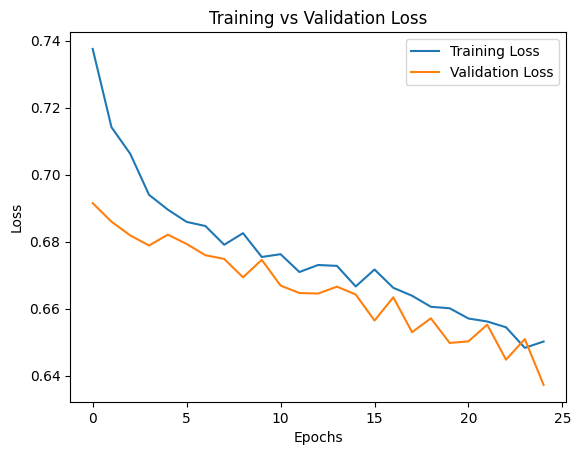

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [ ]:
model.save("skin_cancer_model.h5")


In [ ]:
!pip install streamlit
import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from PIL import Image

model = load_model("skin_cancer_model.keras")
st.set_page_config(page_title="Skin Cancer Detection", layout="centered")

st.title("🧠 Skin Cancer Detection System")
st.write("Upload a skin lesion image to classify it as **Malignant** or **Benign**")

uploaded_file = st.file_uploader("Upload Image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    img = Image.open(uploaded_file).resize((224,224))
    st.image(img, caption="Uploaded Image", use_column_width=True)

    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        st.error(f"⚠️ Malignant Skin Cancer Detected\nConfidence: {prediction*100:.2f}%")
    else:
        st.success(f"✅ Benign Skin Lesion\nConfidence: {(1-prediction)*100:.2f}%")

2026-02-14 09:32:47.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 09:32:47.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 09:32:47.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 09:32:47.309 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 09:32:47.310 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 09:32:47.311 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 09:32:47.312 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-14 09:32:47.313 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar